# Conference Story Figures

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib.patheffects import withStroke
# import geopandas as gpd
# from netCDF4 import Dataset
# import os
# import cv2
# import datetime
# import numba
import pickle
# import pyarrow.parquet as pq
# from shapely.geometry import Point, Polygon
# import inspect
# import glob
# import h5py
from scipy.io import savemat
from pathlib import Path

import importlib
import track

# Development helper: uncomment after editing track.py.
# importlib.reload(track)
# track.switch_region('global')
# det_cfg = track.make_detection_config(
#     'do',
#     do_threshold=50.0,
#     anomaly_min_depth=300.0,
#     cbar_min=10.0,
#     cbar_max=100.0,
# )

本节按会议证据链组织 cache-first 输出：深层 ΔDO 阈值漏斗 → EKE 环境背景 → META 表层对象关联 → McCoy 次表层涡富集。各层使用不同统计对象和分母，不作因果解释。

## DO Threshold Funnel

同一 profile-based ΔDO detector 只改变 prominence threshold，比较候选数量与全球地理组成。

In [2]:
%matplotlib inline
track.switch_region('global')

presentation_do_threshold_summary = track.summarize_do_threshold_sweep(
    thresholds=(20.0, 35.0, 50.0),
    start_year=2002,
    end_year=2023,
    anomaly_min_depth=300.0,
    save_report=True,
)

[RegionConfig] Switched to region 'global': lon[-180.0, 180.0], lat[-90.0, 90.0]
[*] DO threshold sweep summary saved: plot_outputs/do/global_ocean/do_threshold_sweep_summary/do_threshold_sweep_summary_2002_2023_depth300m.parquet
[*] DO threshold sweep summary saved: plot_outputs/do/global_ocean/do_threshold_sweep_summary/do_threshold_sweep_summary_2002_2023_depth300m.csv
[*] DO threshold sweep summary saved: plot_outputs/do/global_ocean/do_threshold_sweep_summary/do_threshold_sweep_summary_2002_2023_depth300m.txt


[*] DO threshold counts/composition figure saved: plot_outputs/do/global_ocean/plot_do_threshold_counts_and_composition/do_threshold_counts_and_composition_2002_2023_depth300m.png


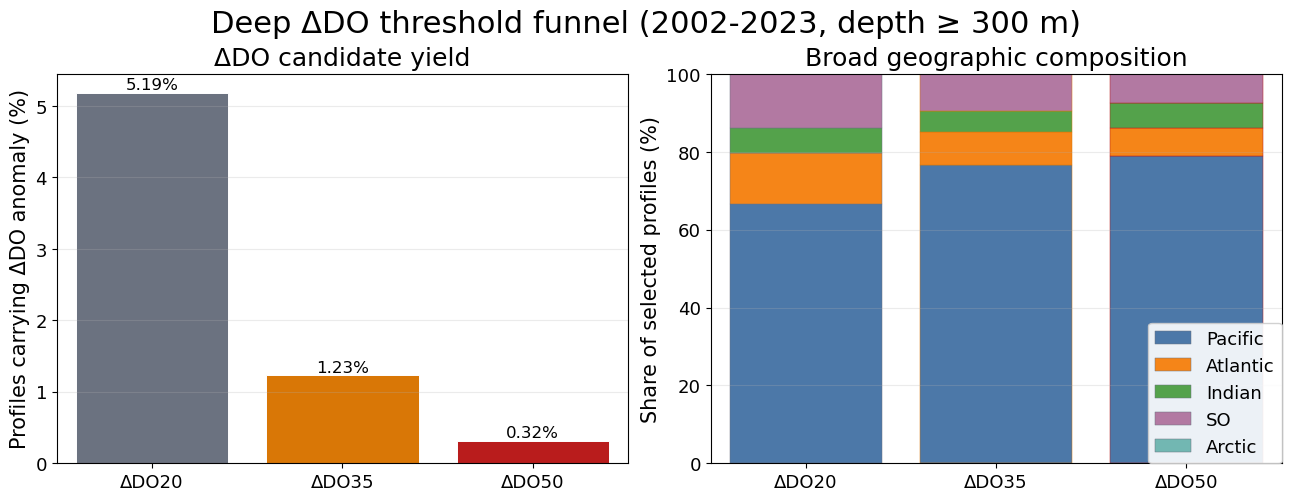

In [3]:
presentation_do_counts_plot = track.plot_do_threshold_counts_and_composition(
    presentation_do_threshold_summary,
    show_fig=True,
    save_fig=True,
)

## EKE Context

EKE 仅作为 mesoscale-active 环境背景。空间对照和 EKE 分箱发生率均使用 sampled-profile 分母；普通 grid-cell p 值不作为证据。

In [4]:
presentation_do_occurrence_summaries = track.build_euler_occurrence_comparison_summaries(
    [
        track.make_detection_config('do', do_threshold=20.0, anomaly_min_depth=300.0),
        track.make_detection_config('do', do_threshold=35.0, anomaly_min_depth=300.0),
        track.make_detection_config('do', do_threshold=50.0, anomaly_min_depth=300.0),
    ],
    start_year=2002,
    end_year=2022,
    grid_step_deg=1.0,
)

Figure saved: plot_outputs/shared/global_ocean/plot_euler_occurrence_comparison/do_threshold_euler_occurrence_2002_2022_depth300m.png


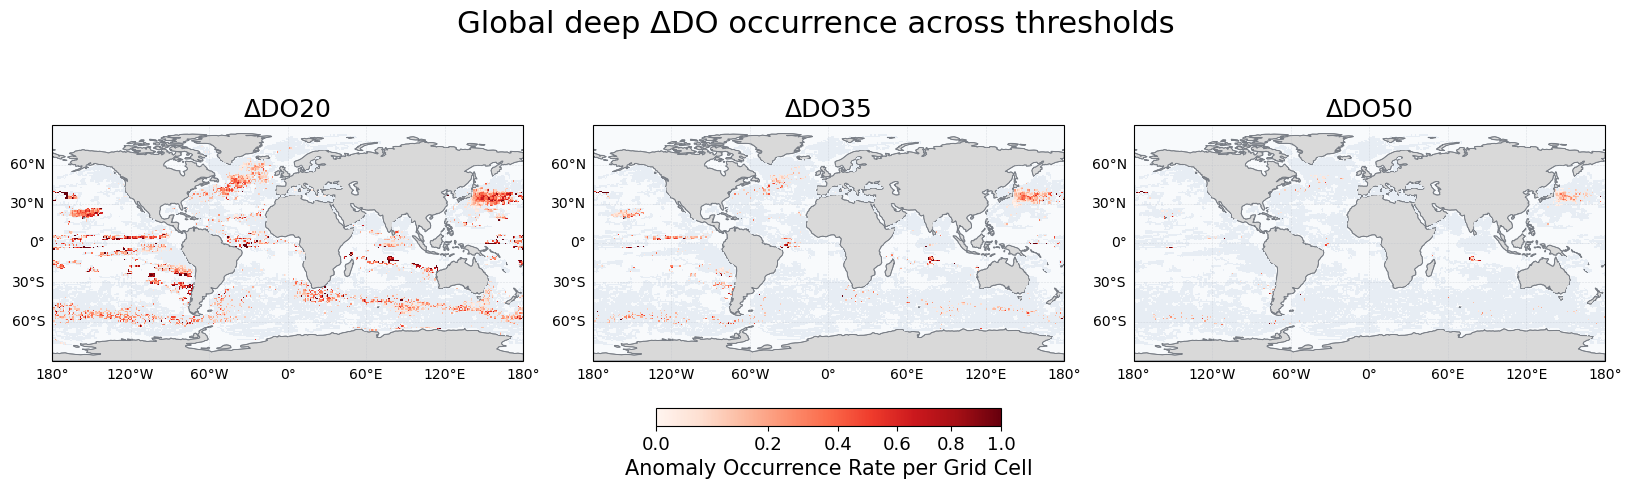

In [5]:
presentation_do_occurrence_plot = track.plot_euler_occurrence_comparison(
    presentation_do_occurrence_summaries,
    labels=('ΔDO20', 'ΔDO35', 'ΔDO50'),
    title='Global deep ΔDO occurrence across thresholds',
    output_name='do_threshold_euler_occurrence_2002_2022_depth300m',
    show_fig=True,
    save_fig=True,
)

In [6]:
presentation_eke_native = track.load_glorys_eke_native(
    Path('GLORYS_processed/eke.zarr'), include_count=False
)
presentation_eke_euler = track.remap_glorys_eke_to_euler_grid(
    presentation_eke_native,
    grid_step_deg=1.0,
    method='linear',
)

[*] DO threshold/EKE spatial comparison saved: plot_outputs/do/global_ocean/plot_do_threshold_eke/do_threshold_eke_spatial_comparison_2002_2022_depth300m.png


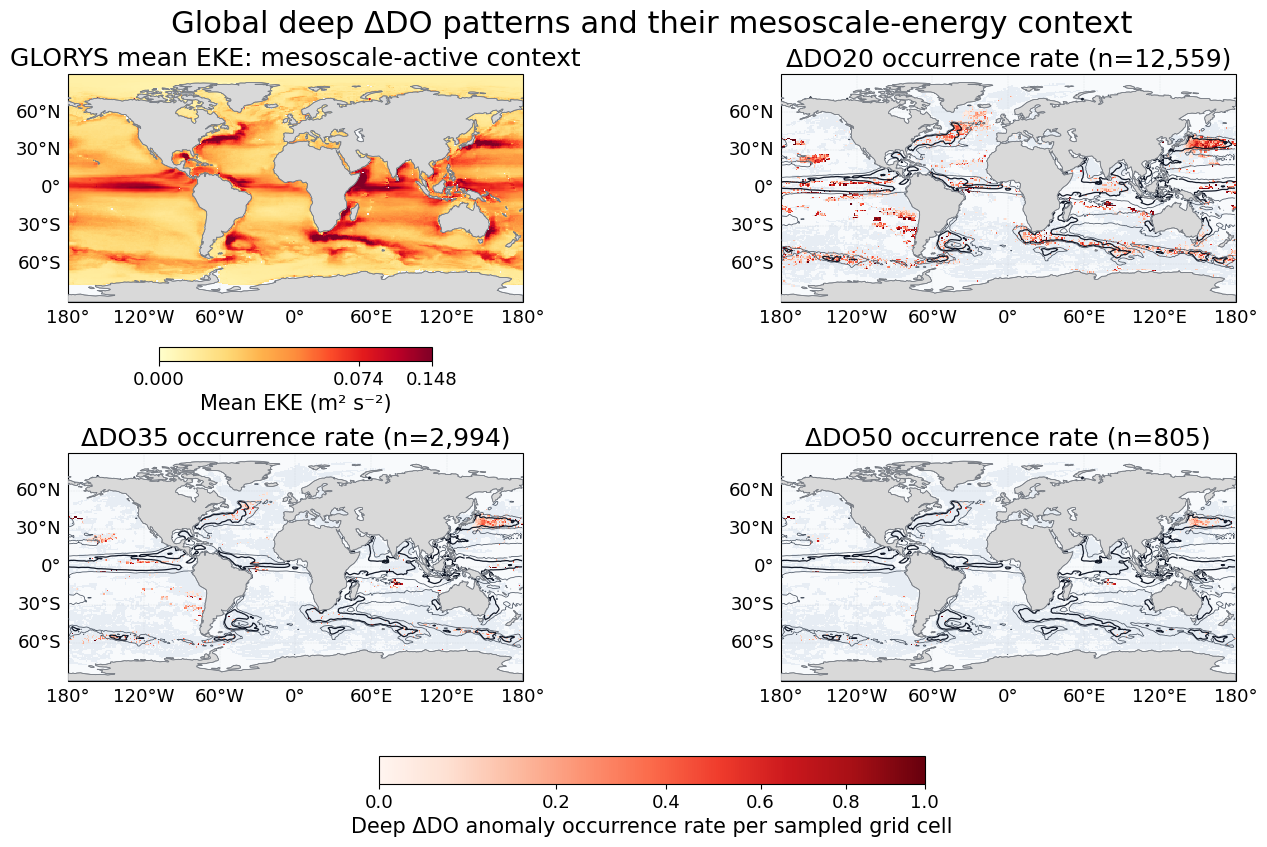

In [7]:
presentation_eke_spatial_plot = track.plot_do_threshold_eke_spatial_comparison(
    presentation_do_occurrence_summaries,
    presentation_eke_euler,
    show_fig=True,
    save_fig=True,
)

In [8]:
presentation_eke_binned_summary = track.build_do_threshold_eke_binned_summary(
    presentation_do_occurrence_summaries,
    presentation_eke_euler,
    n_quantile_bins=5,
    min_profiles_per_cell=1,
    save_data=True,
)

[*] DO threshold/EKE binned summary saved: plot_outputs/do/global_ocean/plot_do_threshold_eke/do_threshold_eke_binned_summary_2002_2022_depth300m.csv


[*] DO threshold/EKE binned relationship saved: plot_outputs/do/global_ocean/plot_do_threshold_eke/do_threshold_eke_binned_relationship_2002_2022_depth300m.png


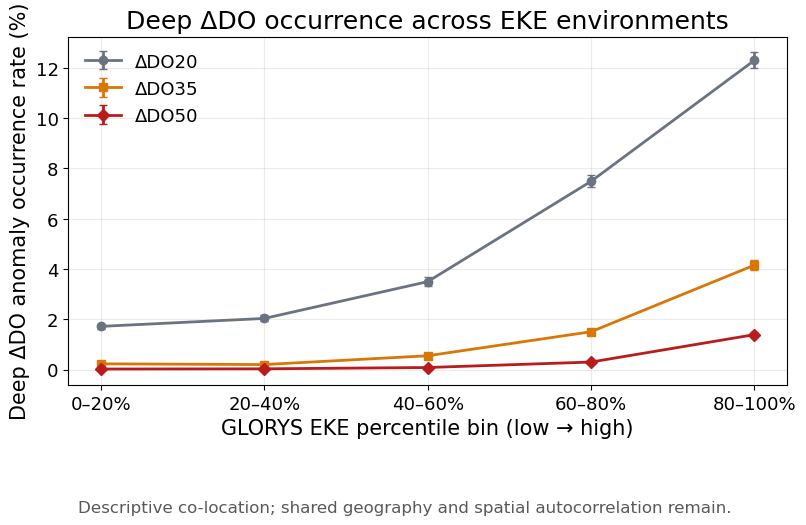

In [9]:
presentation_eke_binned_plot = track.plot_do_threshold_eke_binned_relationship(
    presentation_eke_binned_summary,
    show_fig=True,
    save_fig=True,
)

## META Surface-Object Association

这里展示 anomaly-centered 的 P(META | DO threshold)，与后面的 P(DO threshold | group) 分开。

[*] DO threshold META association figure saved: plot_outputs/do/global_ocean/plot_do_threshold_meta_association/do_threshold_meta_association_2002_2023_depth300m.png


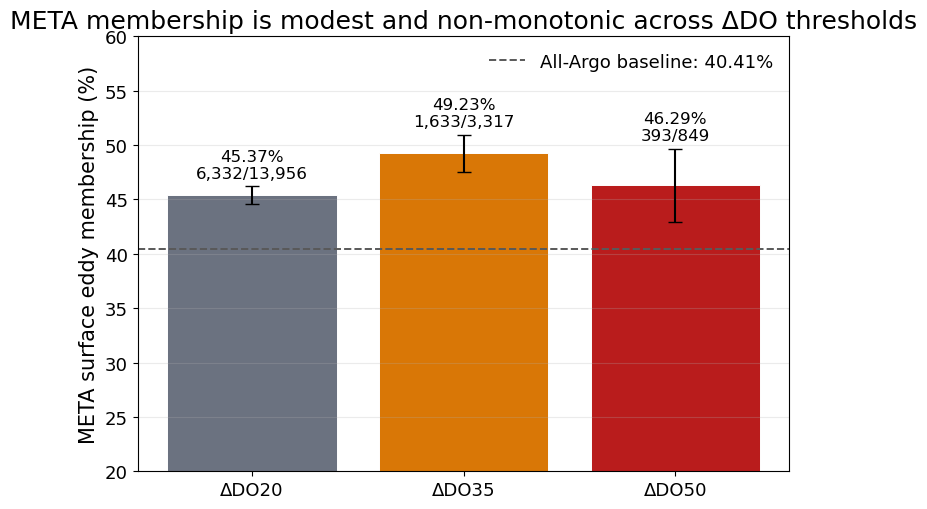

In [10]:
presentation_meta_plot = track.plot_do_threshold_meta_association(
    presentation_do_threshold_summary,
    show_fig=True,
    save_fig=True,
)

## McCoy SCV Evidence

McCoy et al. (2020) 提供独立的 Argo-derived、velocity-confirmed subsurface coherent vortex catalogue。先介绍目录，再比较统一 DO-evaluable 分母下的 carrier frequency。

In [11]:
track.switch_region('global')
presentation_scv_threshold_table = track.build_mccoy_scv_delta_do_threshold_table(
    thresholds=(20.0, 35.0, 50.0),
    baseline_start_year=2002,
    baseline_end_year=2023,
    anomaly_min_depth=300.0,
    force=False,
    save_data=True,
)

[RegionConfig] Switched to region 'global': lon[-180.0, 180.0], lat[-90.0, 90.0]


In [12]:
track.switch_region('global')
presentation_scv_frequency_stats = {}
for threshold in (20.0, 35.0, 50.0):
    cfg = track.make_detection_config(
        'do', do_threshold=threshold, anomaly_min_depth=300.0
    )
    presentation_scv_frequency_stats[threshold] = track.calculate_scv_frequency_statistics(
        detection_config=cfg,
        baseline_start_year=2002,
        baseline_end_year=2023,
        save_report=True,
    )

[RegionConfig] Switched to region 'global': lon[-180.0, 180.0], lat[-90.0, 90.0]
McCoy SCV Frequency Analysis (2002-2023)
Region: global_ocean | Method: do | Depth>=300m
----------------------------------------
[Inside META surface eddy]
  Baseline Argo:  108695/269008 = 40.41%
  ΔDO-anom Argo:  6332/13956 = 45.37%  (orig. FA; OR=1.22, p=4.88e-31)
  McCoy SCVs:     2358/4066 = 57.99%  (OR=2.04, p=4.51e-111)
----------------------------------------
[Carry significant ΔDO (≥ threshold)]
  Baseline DO Argo: 13956/230117 = 6.065%
  In META eddy:     6332/93161 = 6.797%  (OR=1.13 vs baseline)
  McCoy SCVs:       67/244 = 27.46%  (OR=5.86 vs baseline)
Report saved to: plot_outputs/do/global_ocean/statistics/scv_frequency_stats_2002_2023_do20_depth300m.txt
McCoy SCV Frequency Analysis (2002-2023)
Region: global_ocean | Method: do | Depth>=300m
----------------------------------------
[Inside META surface eddy]
  Baseline Argo:  108695/269008 = 40.41%
  ΔDO-anom Argo:  1633/3317 = 49.23%  (ori

In [13]:
presentation_scv_threshold_summary = track.summarize_scv_do_threshold_sweep(
    presentation_scv_threshold_table,
    thresholds=(20.0, 35.0, 50.0),
    baseline_start_year=2002,
    baseline_end_year=2023,
    anomaly_min_depth=300.0,
    save_data=True,
)

[*] SCV DO threshold sweep saved: plot_outputs/do/global_ocean/scv_do_threshold_sweep/scv_do_threshold_sweep_2002_2023_depth300m.parquet


[*] McCoy SCV catalogue context figure saved: plot_outputs/do/global_ocean/plot_mccoy_scv_catalog_context/mccoy_scv_catalog_context.png


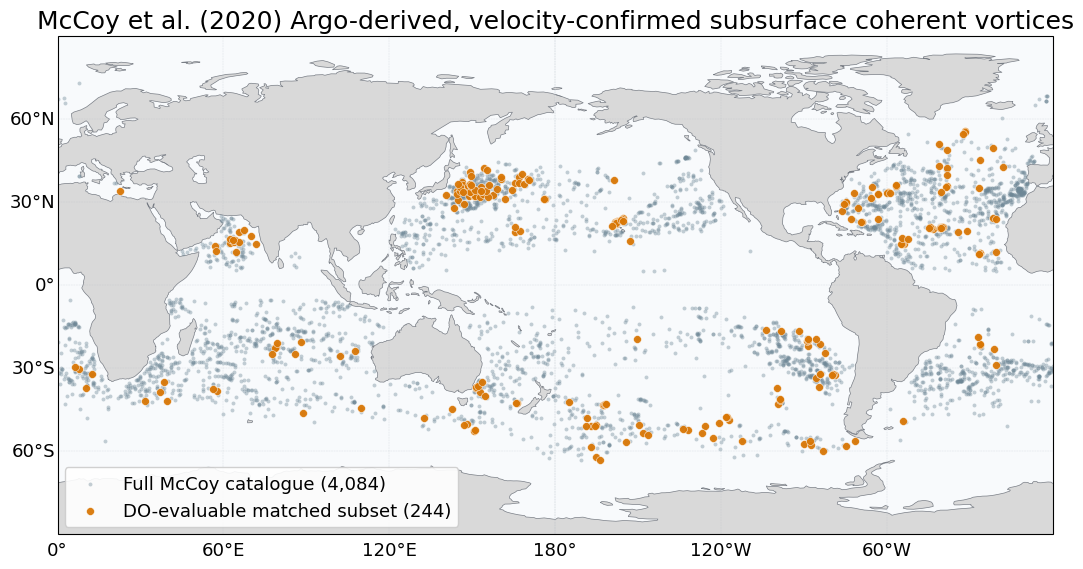

In [14]:
presentation_scv_catalog_plot = track.plot_mccoy_scv_catalog_context(
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

[*] SCV DO threshold enrichment figure saved: plot_outputs/do/global_ocean/scv_do_threshold_sweep/scv_do_threshold_enrichment_2002_2023_depth300m.png


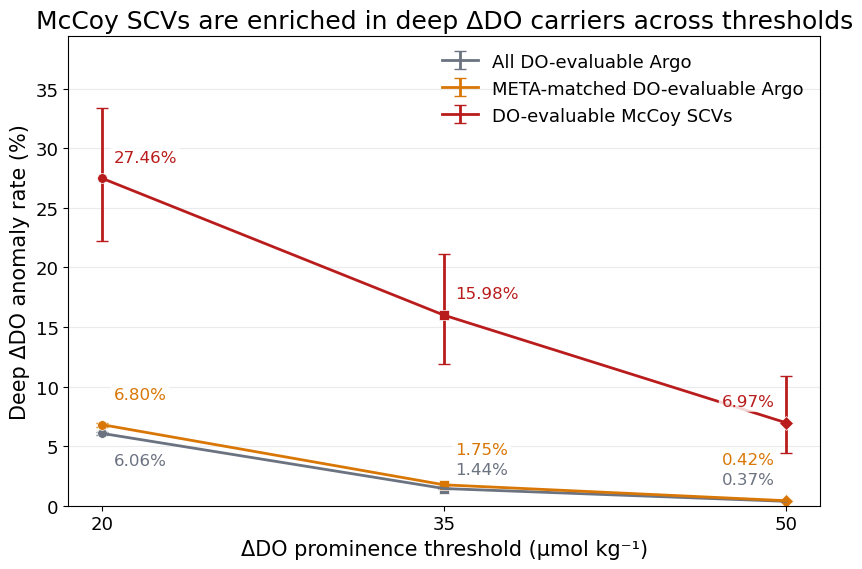

[*] SCV DO threshold enrichment figure saved: plot_outputs/do/global_ocean/scv_do_threshold_sweep/scv_do_threshold_enrichment_2002_2023_depth300m_log.png


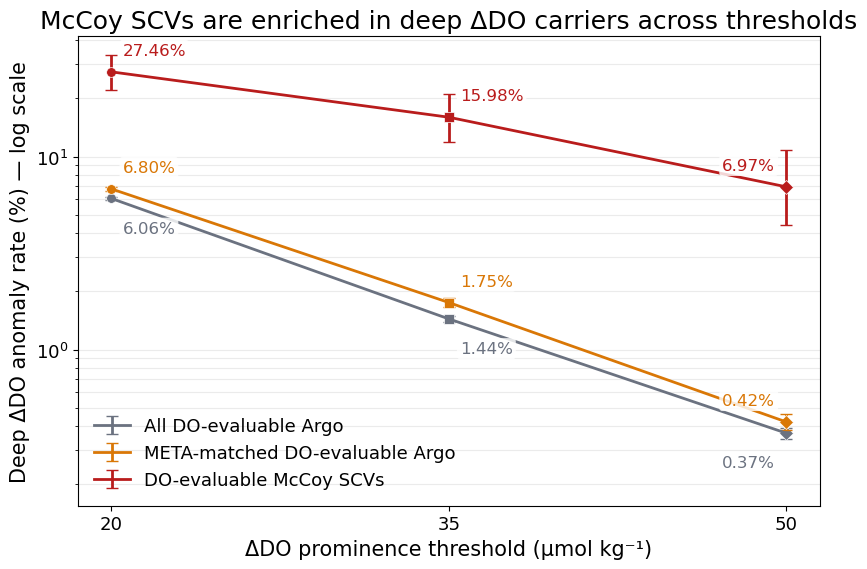

In [15]:
presentation_scv_enrichment_linear_plot = track.plot_scv_do_threshold_enrichment(
    presentation_scv_threshold_summary,
    show_fig=True,
    save_fig=True,
    log_scale=False,
)
presentation_scv_enrichment_log_plot = track.plot_scv_do_threshold_enrichment(
    presentation_scv_threshold_summary,
    show_fig=True,
    save_fig=True,
    log_scale=True,
)

## SCV Threshold Details

ΔDO20、ΔDO35 与 ΔDO50 的 detailed frequency、carrier geography 和 representation status。这组图用于阈值稳健性与 backup comparison；主叙事仍以汇总 threshold-enrichment plot 为准。

### Frequency Enrichment

每张图比较 all DO-evaluable Argo、META-matched Argo 与 McCoy SCVs 的 `P(DO_t | group)`；三阈值使用各自的 cached frequency summary。

[*] SCV frequency enrichment saved: plot_outputs/do/global_ocean/plot_scv_frequency_enrichment/scv_frequency_enrichment_do20_depth300m.png


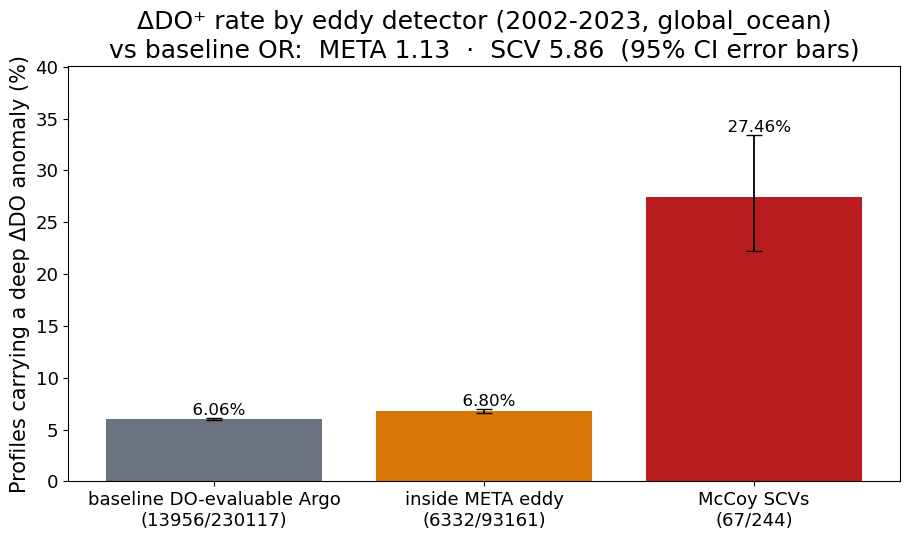

In [16]:
presentation_do20_config = track.make_detection_config(
    'do', do_threshold=20.0, anomaly_min_depth=300.0
)
presentation_do20_frequency_plot = track.plot_scv_frequency_enrichment(
    detection_config=presentation_do20_config,
    show_fig=True,
    save_fig=True,
)

[*] SCV frequency enrichment saved: plot_outputs/do/global_ocean/plot_scv_frequency_enrichment/scv_frequency_enrichment_do35_depth300m.png


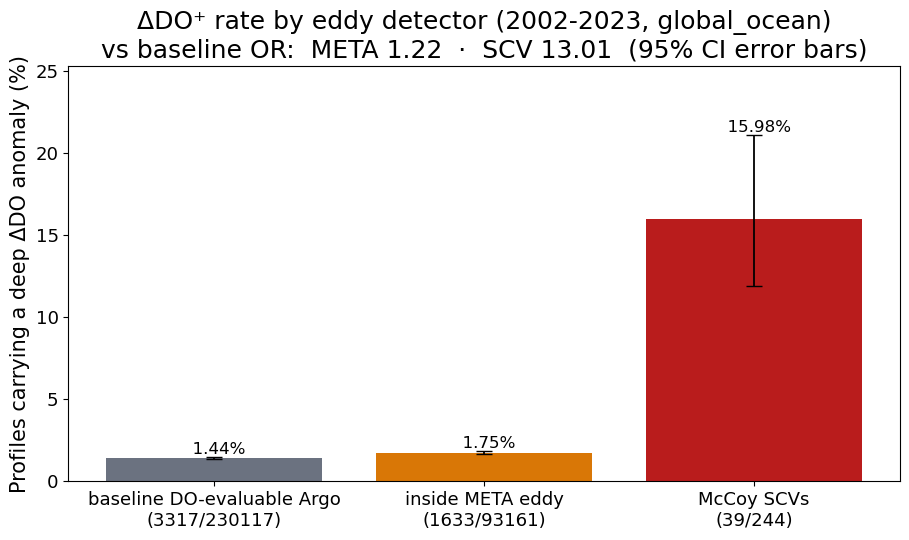

In [17]:
presentation_do35_config = track.make_detection_config(
    'do', do_threshold=35.0, anomaly_min_depth=300.0
)
presentation_do35_frequency_plot = track.plot_scv_frequency_enrichment(
    detection_config=presentation_do35_config,
    show_fig=True,
    save_fig=True,
)

[*] SCV frequency enrichment saved: plot_outputs/do/global_ocean/plot_scv_frequency_enrichment/scv_frequency_enrichment_do50_depth300m.png


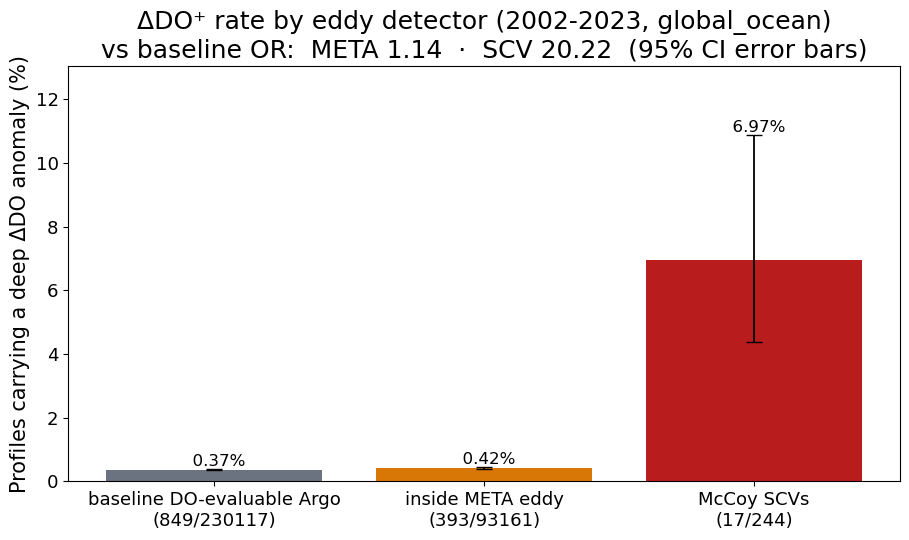

In [18]:
presentation_do50_config = track.make_detection_config(
    'do', do_threshold=50.0, anomaly_min_depth=300.0
)
presentation_do50_frequency_plot = track.plot_scv_frequency_enrichment(
    detection_config=presentation_do50_config,
    show_fig=True,
    save_fig=True,
)

### Carrier Geography

灰点为 DO-evaluable McCoy SCVs，彩色点为对应阈值 carrier。此处不按 GLORYS/META representation status 筛选。

[*] SCV DO carrier distribution saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_distribution/scv_do_carrier_distribution_do20_depth300m.png


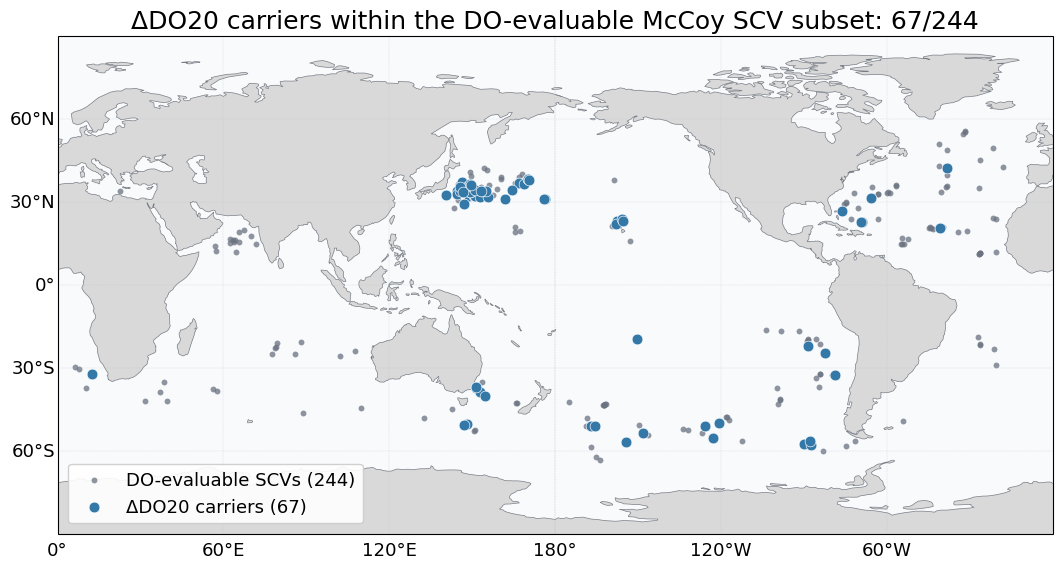

In [19]:
presentation_do20_distribution_plot = track.plot_scv_do_carrier_distribution(
    20.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

[*] SCV DO carrier distribution saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_distribution/scv_do_carrier_distribution_do35_depth300m.png


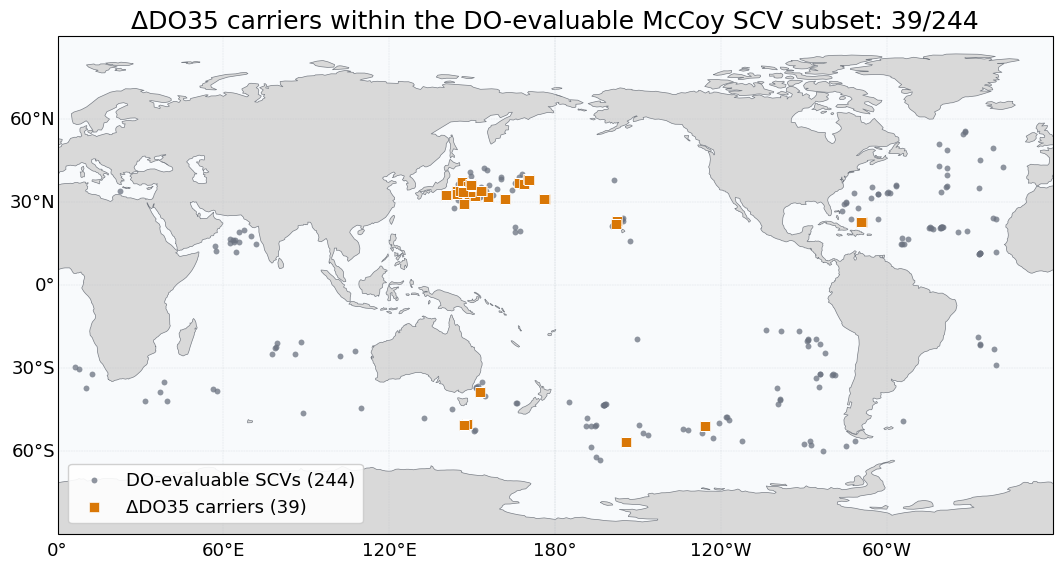

In [20]:
presentation_do35_distribution_plot = track.plot_scv_do_carrier_distribution(
    35.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

[*] SCV DO carrier distribution saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_distribution/scv_do_carrier_distribution_do50_depth300m.png


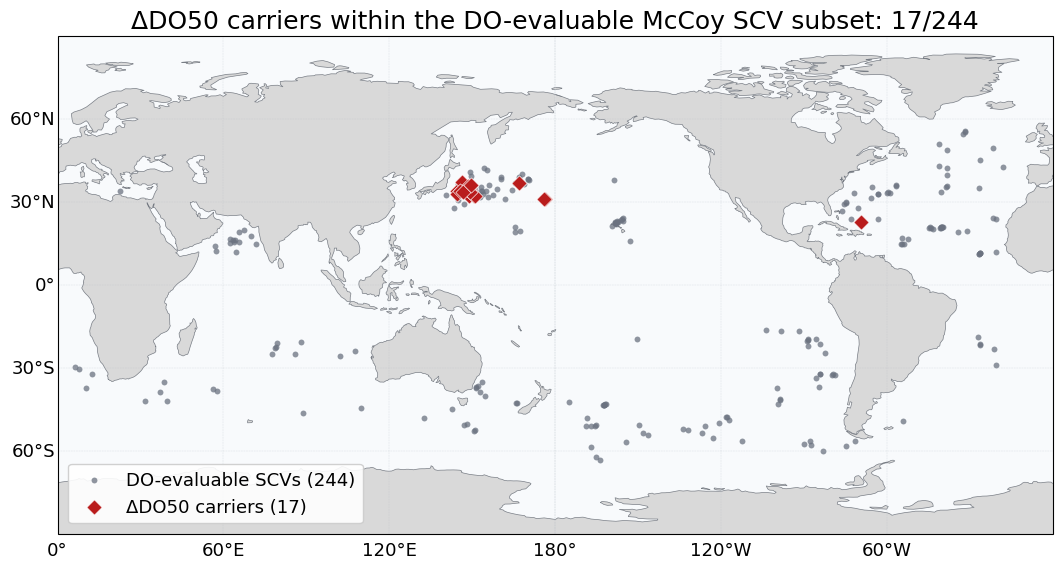

[*] SCV DO carrier distribution comparison saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_distribution/scv_do_carrier_distribution_all_thresholds_depth300m.png


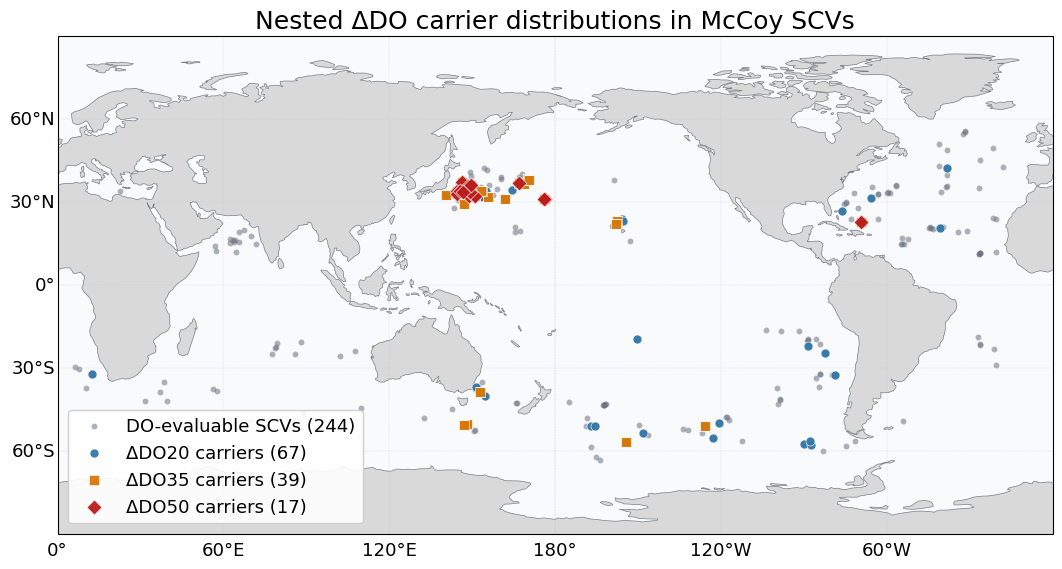

In [21]:
presentation_do50_distribution_plot = track.plot_scv_do_carrier_distribution(
    50.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)
presentation_scv_distribution_comparison_plot = track.plot_scv_do_carrier_distribution_comparison(
    thresholds=(20.0, 35.0, 50.0),
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

### Representation Status

所有 carrier 均保留；GLORYS/META criterion 无法判定的对象单列为 unavailable。

[*] SCV DO carrier representation status saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_representation_status/scv_do_carrier_representation_status_do20_depth300m.png


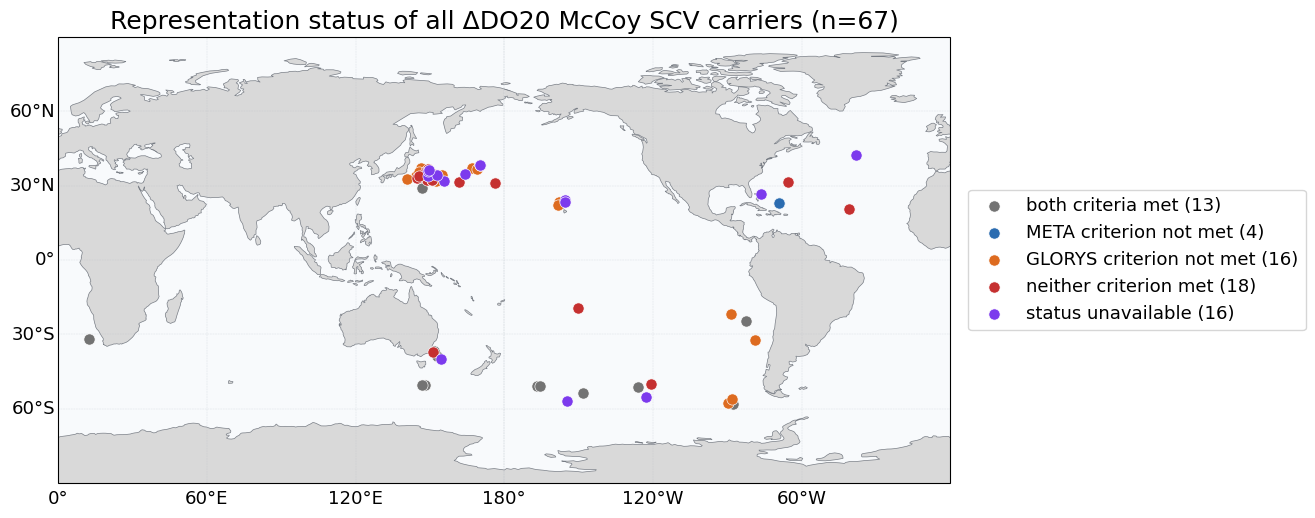

In [22]:
presentation_do20_representation_plot = track.plot_scv_do_carrier_representation_status(
    20.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

[*] SCV DO carrier representation status saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_representation_status/scv_do_carrier_representation_status_do35_depth300m.png


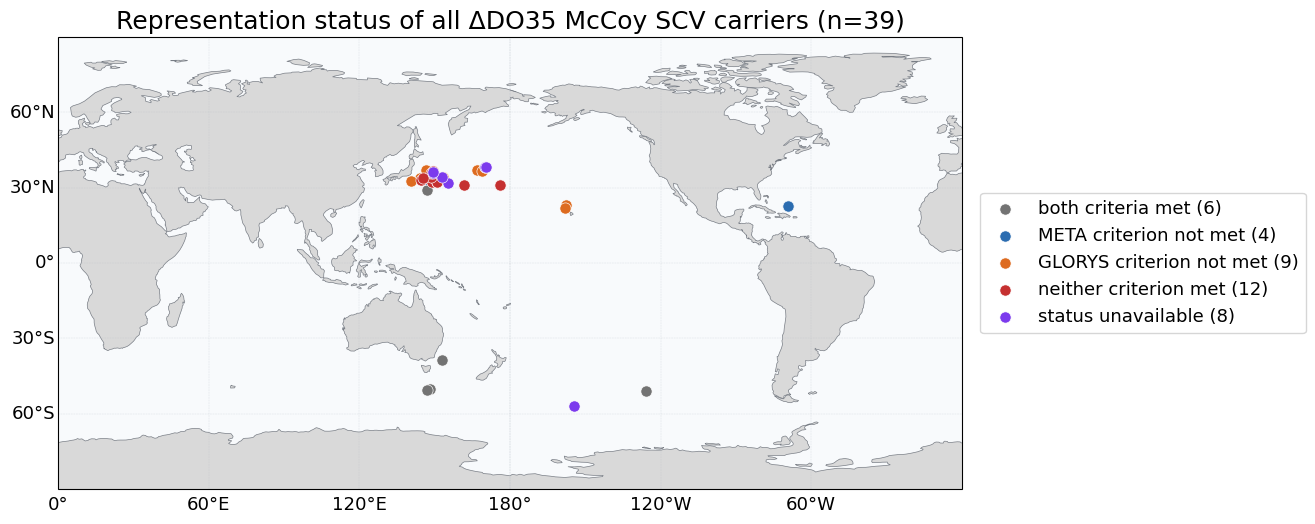

In [23]:
presentation_do35_representation_plot = track.plot_scv_do_carrier_representation_status(
    35.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

[*] SCV DO carrier representation status saved: plot_outputs/do/global_ocean/plot_scv_do_carrier_representation_status/scv_do_carrier_representation_status_do50_depth300m.png


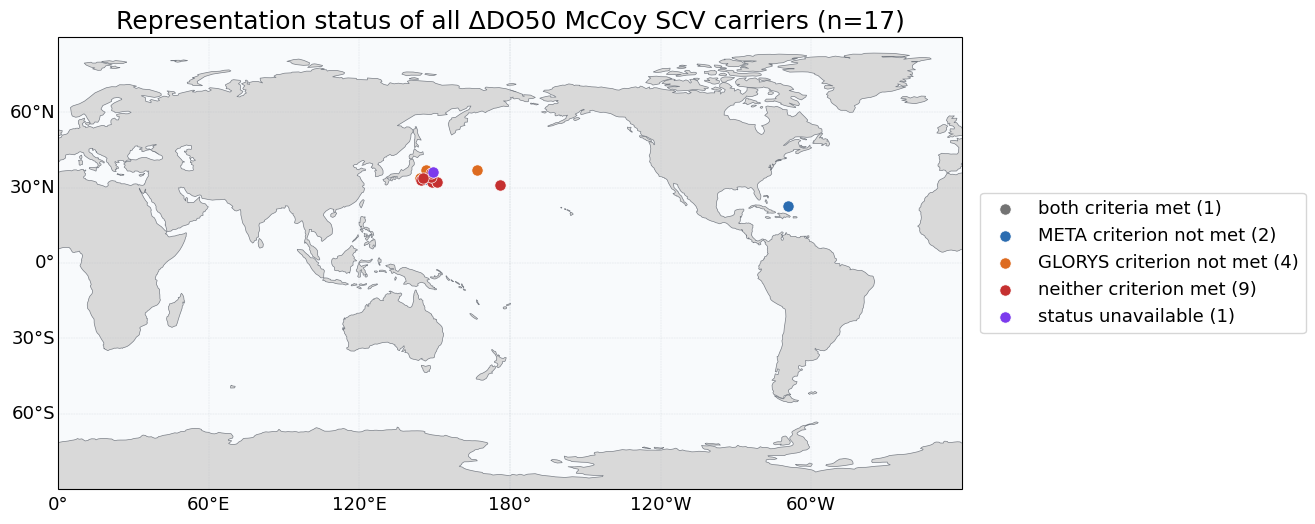

In [24]:
presentation_do50_representation_plot = track.plot_scv_do_carrier_representation_status(
    50.0,
    threshold_table=presentation_scv_threshold_table,
    show_fig=True,
    save_fig=True,
)

### Full McCoy Catalogue Context

[*] McCoy data-gap atlas saved: plot_outputs/do/global_ocean/plot_mccoy_datagap_atlas/mccoy_datagap_atlas_do50_depth300m.png


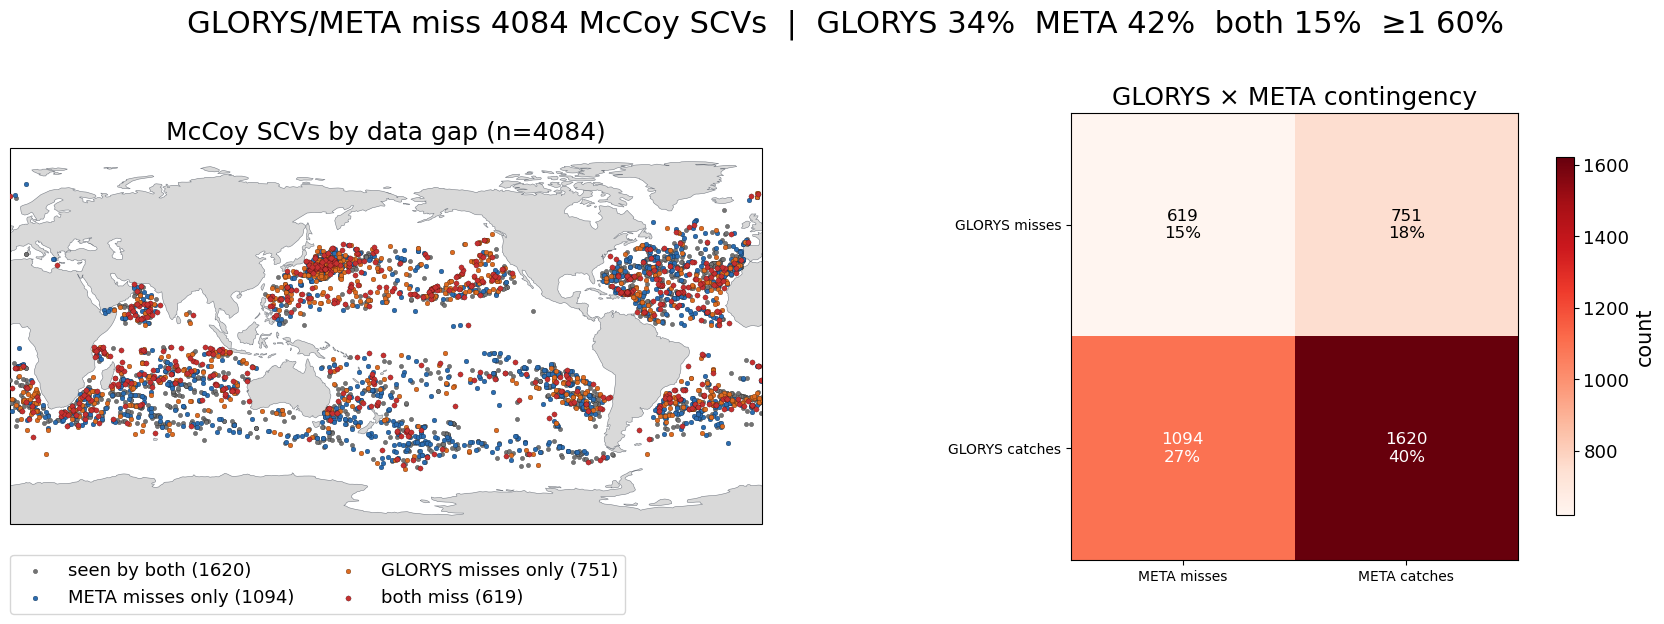

In [25]:
presentation_mccoy_atlas = track.plot_mccoy_datagap_atlas(
    detection_config=presentation_do50_config,
    show_fig=True,
    save_fig=True,
)